In [16]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt

from physion.analysis import tools

sys.path.append('../scripts')
from distinct_rest_vs_active import compute_high_arousal_cond
from Behavioral_param import plot_loco_pupil

import random
from matplotlib.ticker import MultipleLocator

# NDNF 2022

In [2]:
dFoF_options = {'roi_to_neuropil_fluo_inclusion_factor' : 1.0, # ratio to discard ROIs with weak fluo compared to neuropil
                 'method_for_F0' : 'sliding_percentile', # either 'minimum', 'percentile', 'sliding_minimum', or 'sliding_percentile'
                 'sliding_window' : 300. , # seconds (used only if METHOD= 'sliding_minimum' | 'sliding_percentile')
                 'percentile' : 10. , # for baseline (used only if METHOD= 'percentile' | 'sliding_percentile')
                 'neuropil_correction_factor' : 0.8 }# fraction of neuropil substracted to fluorescence

In [3]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 12.8s) 


## Example with 1 file (check index below)

In [4]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)

data.build_dFoF(**dFoF_options, verbose=True)


calculating dF/F with method "sliding_percentile" [...]

  ** 3 ROIs were discarded with the positive F0 criterion (4.4%) ** 

-> dFoF calculus done !  (calculation took 0.1s)


In [5]:
data.build_pupil_diameter()
data.build_running_speed()
print(data.pupil_diameter)
print(data.running_speed)

[3.33300101 3.35461698 3.36052326 ... 3.83071908 4.03233816 4.04108442]
[2.53115852 2.55263261 2.57177009 ... 0.67059207 0.66529663 0.65537068]


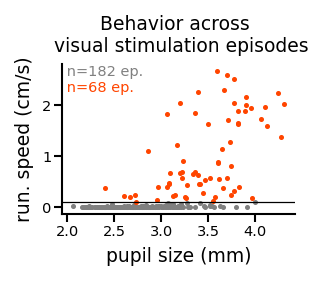

In [6]:
running_speed_threshold=0.1
pupil_threshold = 2.9
fig, ax = plot_loco_pupil(data, running_speed_threshold=running_speed_threshold, pupil_threshold=pupil_threshold, metric="locomotion", mylabel=False, prestim_dur =0)
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_locomotion_pupil1.png", dpi=300, bbox_inches='tight')

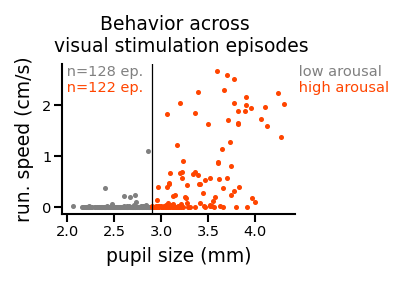

In [7]:
fig, ax = plot_loco_pupil(data, running_speed_threshold=running_speed_threshold, pupil_threshold=pupil_threshold, metric="pupil", mylabel=True)
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_locomotion_pupil2.png", dpi=300, bbox_inches='tight')


calculating dF/F with method "sliding_percentile" [...]

  ** 3 ROIs were discarded with the positive F0 criterion (4.4%) ** 

-> dFoF calculus done !  (calculation took 0.1s)


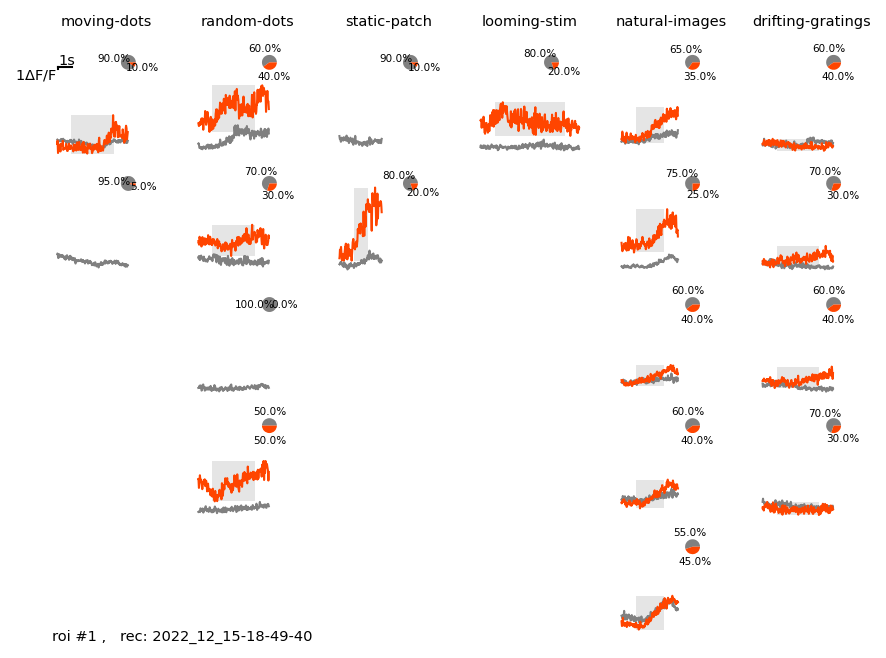

In [10]:
dataIndex, roiIndex = 2, 0
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(**dFoF_options, verbose=True)
fig = plot_average_visually_evoked_activity_NDNF(data, roiIndex=roiIndex, pupil_threshold=2.9, running_speed_threshold=0.1, metric='locomotion')
fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/behavior_different_stim.png", dpi=300, bbox_inches='tight')

### plot locomotion only

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 3 modalities [...]
  -> [ok] episodes ready !
Specific episode # 33 (['resting'])
value to compare to threshold :  0.01816634016837026


0

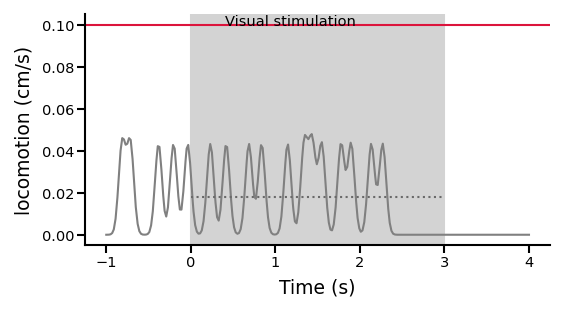

In [13]:
#Load episodes by protocol!
protocol = "moving-dots"
pre_stim = 1

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol, 
                 prestim_duration=pre_stim)

HMcond = compute_high_arousal_cond(Ep, 
                                   pre_stim = pre_stim,
                                   pupil_threshold = 0.29, 
                                   running_speed_threshold = 0.1, 
                                   metric = 'locomotion')

epi_num = random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  #34 is active   #2 is weird #22

plot_locomotion(Ep, 
                HMcond,  
                episode_n = epi_num, 
                pre_stim = pre_stim)

### plot dFoF vs locomotion

### Specific ROI, specific episode

In [ ]:
protocol = 'moving-dots'
pre_stim = 1

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                   pre_stim = pre_stim,
                                   pupil_threshold = 0.29, 
                                   running_speed_threshold = 0.1, 
                                   metric = 'locomotion')

In [ ]:
roi = random.randint(0, Ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  #34 is active

plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=False, 
                     resting=False)

### Specific episode, average ROI

In [ ]:
epi_num = 34 #random.randint(0, Ep.dFoF.shape[0]-1) #chosen randomly  
plot_dFoF_locomotion(Ep, HMcond, episode_n = epi_num)

### Specific ROI, average episodes

In [ ]:
roi = 17 #random.randint(0, Ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
roi = 14 #random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

## All files

In [ ]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='locomotion', mylabel=False)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    
for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/all_behavior_locomotion_pupil1.png", dpi=300, bbox_inches='tight')

In [ ]:
rows = 3
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], metric='pupil', mylabel=False)
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    
for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

fig.savefig("C:/Users/laura.gonzalez/Output_expe/In_Vivo/NDNF/Behavior/all_behavior_locomotion_pupil2.png", dpi=300, bbox_inches='tight')

### ALL files, average ROI, average episodes

In [ ]:
all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     protocol_id=0,
                     quantities=['dFoF', 'running_speed', 'pupil'])
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

In [ ]:
print(df)

In [ ]:
dataset = "NDNF"
protocol = "moving-dots"
print("dataset : ", dataset)
print("protocol : ", protocol)

plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

### test other protocols

In [ ]:
protocol = 'moving-dots'

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### random dots

In [ ]:
protocol = 'random-dots'

Ep = EpisodeData(data, 
                 quantities=['dFoF', 'running_speed', 'pupil'], 
                 protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### static patch

In [ ]:
protocol = 'static-patch'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### looming stim

In [ ]:
protocol = 'looming-stim'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Natural images 4 repeats

In [ ]:
protocol = 'Natural-Images-4-repeats'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### drifting gratings

In [ ]:
protocol = 'drifting-gratings'
Ep = EpisodeData(data, quantities=['dFoF', 'running_speed', 'pupil'], protocol_name=protocol)

HMcond = compute_high_arousal_cond(Ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
print("Protocol : ", protocol)
plot_dFoF_locomotion(Ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### for all files

In [ ]:
dataset = "NDNF"

In [ ]:
protocol = "moving-dots"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

In [ ]:
protocol = "random-dots"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

In [ ]:
protocol = "static-patch"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

In [ ]:
protocol = "looming-stim"

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

In [ ]:
protocol = 'Natural-Images-4-repeats'

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

In [ ]:
protocol = 'drifting-gratings'

all_ep = []
all_HMcond = []
df = pd.DataFrame()

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                     prestim_duration=0,
                     quantities=['dFoF', 'running_speed', 'pupil'], 
                     protocol_name=protocol)
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                        pupil_threshold = 0.29, 
                                        running_speed_threshold = 0.1, 
                                        metric = 'locomotion')
    all_HMcond.append(HMcond)
    
    new_row = pd.DataFrame({
    'File ID': [dataIndex],
    'number of ROIs': [ep.dFoF.shape[1]],
    'number of episodes': [ep.dFoF.shape[0]],
    'number of active episodes': [np.sum(HMcond)], 
    'proportion of active episodes (%)': [(np.sum(HMcond)/ep.dFoF.shape[0])*100]})
    df = pd.concat([df, new_row], ignore_index=True)

print("dataset : ", dataset)
print("protocol : ", protocol)
plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         general=False, 
                         active=True, 
                         resting=True)

---------------------

# SST Keta vs Saline Cibele and Sofia 2024-2025

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
#print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 4
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)


for i in range(rows*cols-len(SESSIONS['files'])):
    AX[-1][i*(-1) - 1].axis('off')

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

### Specific ROI, specific episode

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

### Specific ROI, average episodes

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### Average ROI, average episodes

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=False, 
                     active=True, 
                     resting=True)

### ALL files, average ROI, average episodes

In [ ]:
all_ep = []
all_HMcond = []

for dataIndex in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][dataIndex], verbose=False)
    data.build_dFoF(verbose=False)
    ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])
    all_ep.append(ep)

    HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')
    all_HMcond.append(HMcond)

all_HMcond = np.concatenate(all_HMcond)

In [ ]:
print(f"{len(SESSIONS['files'])} files")

plot_dFoF_locomotion_all(all_ep, 
                         all_HMcond, 
                         roi_n=None, 
                         episode_n = None, 
                         general=True, 
                         active=True, 
                         resting=True)

---

# SST Keta vs Saline Taddy Yann 2023  --- not enough data!!!

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','SST-Ketamine-vs-Saline', 'All_NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

In [ ]:
dataIndex = 4
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
data.build_running_speed()
data.build_pupil_diameter()
print(data.dFoF.shape)
print(data.pupil_diameter.shape)
print(data.running_speed.shape)

In [ ]:
fig, ax = plot_behavior_in_episodes(data, pupil_threshold = 2.9, running_speed_threshold=0.1, metric='locomotion')
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='orangered', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='grey', xycoords='axes fraction', va='top')

In [ ]:
rows = 1
cols = 5
fig, AX = pt.plt.subplots(rows, cols, figsize=(12,2))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    try:
        data = Data(filename, verbose=False)
        plot_behavior_in_episodes(data, ax=AX[f], running_speed_threshold=0.1, metric='locomotion')
    except Exception as e:
        print(f"Error{e}")
    AX[f].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)

In [ ]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

HMcond = compute_high_arousal_cond(ep, 
                                    pupil_threshold = 0.29, 
                                    running_speed_threshold = 0.1, 
                                    metric = 'locomotion')

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17
epi_num = random.randint(0, ep.dFoF.shape[0]-1) #chosen randomly  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = epi_num, 
                     general=True, 
                     active=True, 
                     resting=True)

In [ ]:
roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly  #roi=17  

plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=roi, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)

In [ ]:
plot_dFoF_locomotion(ep, 
                     HMcond, 
                     roi_n=None, 
                     episode_n = None, 
                     general=True, 
                     active=False, 
                     resting=False)